In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qls
from molecules import CaOH, CaH, mu_N, gI
import pandas as pd
from scipy.constants import h, k
%matplotlib inline

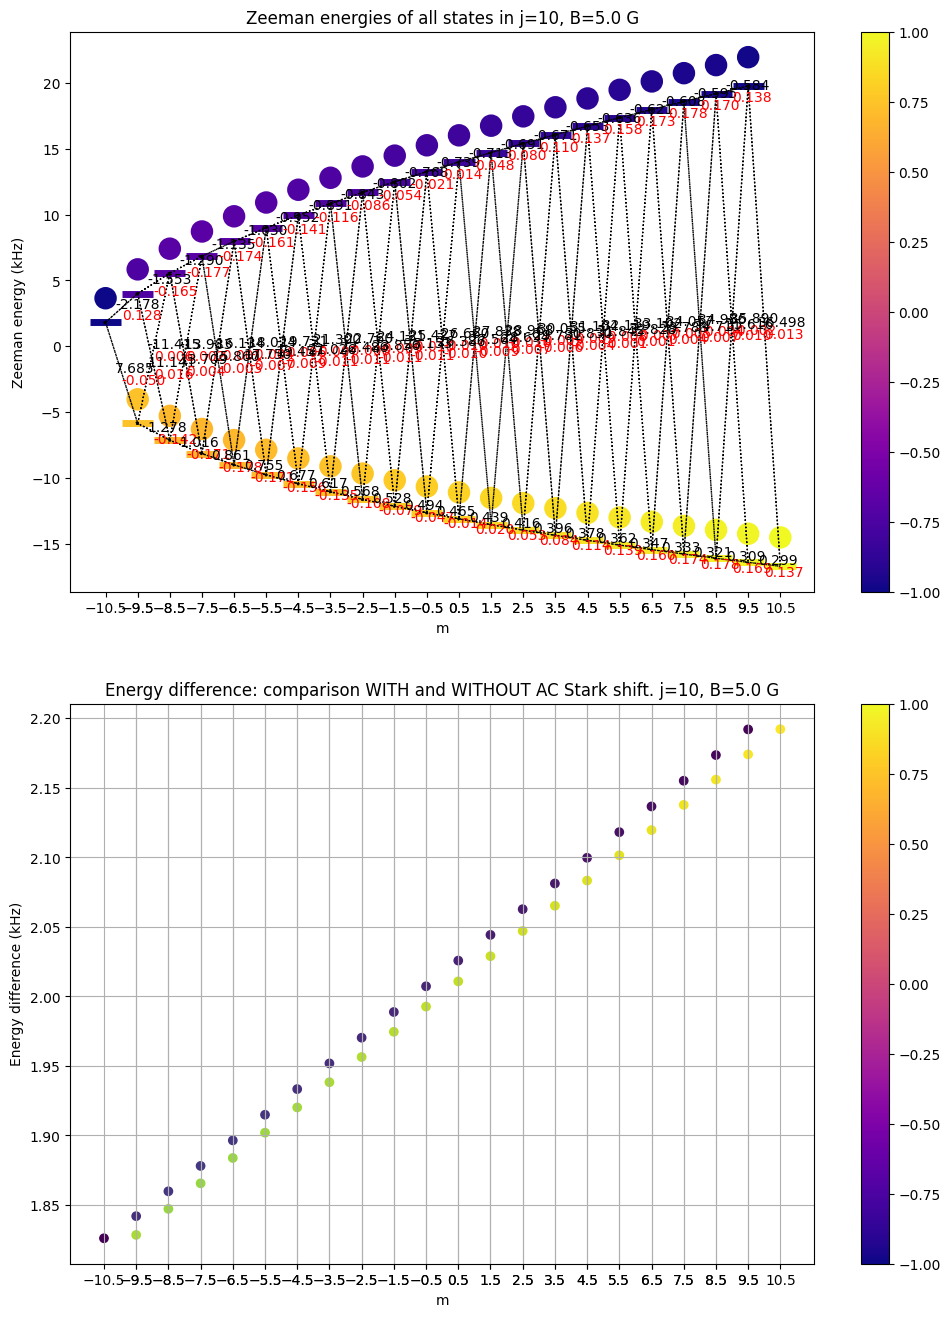

In [2]:
j = 10
caoh = CaOH.from_file(b_field_gauss=5.0, j_max=50)

rabi_rate_mhz_1 = 0.002
rabi_rate_mhz_2 = 0.004
q1 = qls.Polarization(1, 0, 0)
q2 = qls.Polarization(0, 0, 1)
data_ac = [rabi_rate_mhz_1, rabi_rate_mhz_2, q1, q2]

caoh.prova(j, data_ac)

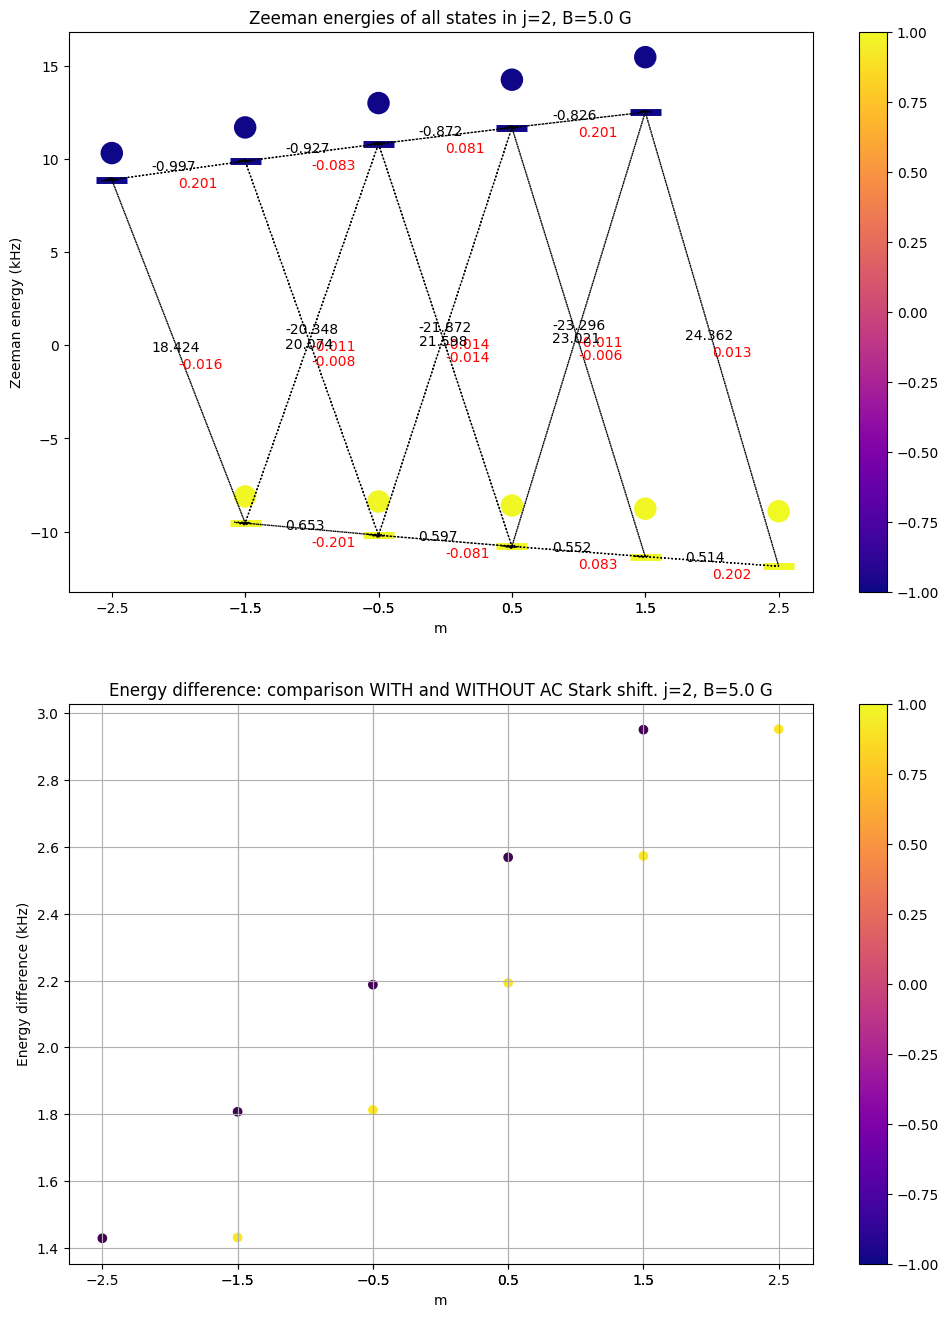

In [3]:
j = 2
caoh = CaOH.from_file(b_field_gauss=5.0, j_max=50)
rabi_rate_mhz_1 = 0.002
rabi_rate_mhz_2 = 0.004
q1 = qls.Polarization(1, 0, 0)
q2 = qls.Polarization(0, 0, 1)

data_ac = [rabi_rate_mhz_1, rabi_rate_mhz_2, q1, q2]

caoh.prova(j, data_ac)

### No pumping. Different B; AC stark

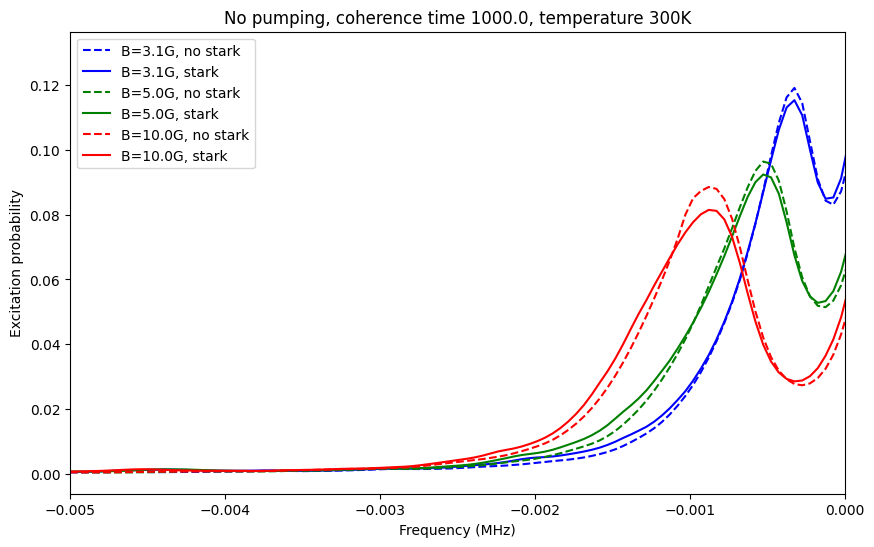

In [4]:
b_fields_gauss = [3.1, 5.0, 10.0]
j_max = 50
temperature = 300

duration_us = 1000.0
max_frequency_mhz = 0.005
scan_points = 200
dephased = True
coherence_time_us = 1000.0
is_minus = True



q1 = qls.Polarization(1, 0, 0)
q2 = qls.Polarization(0, 1, 0)
rabi_rate_mhz_1 = - 2*np.pi*0.001
rabi_rate_mhz_2 = - 2*np.pi*0.002


fig, ax = plt.subplots(figsize=(10, 6))

b_fields_gauss = [3.1, 5.0, 10.0]
colors = ["blue", "green", "red"]

for b, color in zip(b_fields_gauss, colors):
    caoh = CaOH.from_file(b_field_gauss=b, j_max=j_max)
    states = qls.States(caoh, temperature)

    # Ideals
    signature_transitions = np.array([caoh.transition_df.loc[caoh.transition_df["j"]==j].iloc[0]["energy_diff"] * 1e-3 for j in range(caoh.j_max+1)])
    # ax.bar(signature_transitions, states.j_distribution(), color="red", width=0.0005, alpha=0.1, label = "Ideal")

    # Without AC
    frequencies, exc_probs = qls.get_spectrum(caoh, states.dist, duration_us, rabi_rate_mhz_1, max_frequency_mhz, scan_points, dephased, coherence_time_us, is_minus)
    plt.plot(frequencies, exc_probs, color=color, label=f"B={b}G, no stark", linestyle="--")

    # With AC
    ac_stark_shifts = qls.get_ac_stark_shifts(caoh, rabi_rate_mhz_1, rabi_rate_mhz_2, q1, q2)
    caoh.state_df["zeeman_energy_khz"] += ac_stark_shifts * 1e3     # Update state_df zeeman energy
    
    # Reset the transitions and create the new transitions with these new energy levels
    caoh.transition_df = pd.DataFrame()     
    caoh.init_transition_dataframe()
    
    frequencies, exc_probs = qls.get_spectrum(caoh, states.dist, duration_us, rabi_rate_mhz_1, max_frequency_mhz, scan_points, dephased, coherence_time_us, is_minus)
    plt.plot(frequencies, exc_probs, color=color, label=f"B={b}G, stark")
    
plt.legend()
plt.xlabel("Frequency (MHz)")
plt.ylabel("Excitation probability")
# plt.yscale("log")
plt.xlim([-max_frequency_mhz, 0])
plt.title(f"No pumping, coherence time {coherence_time_us}, temperature 300K")
plt.show()


### No pumping. AC with different rabi_rate_mhz_2. <br> 
- B = 5.0 G
- q1 = (1,0,0)
- q2 = (0,1,0)
- rabi_rate_2 = [0.001, 0.002, 0.004]

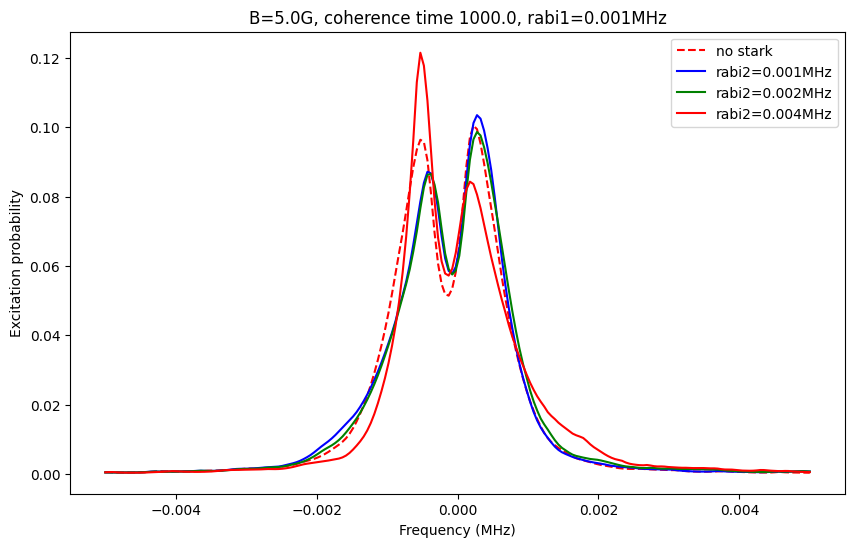

In [5]:
j_max = 50
b_fields_gauss = 5.0

caoh = CaOH.from_file(b_field_gauss=b_fields_gauss, j_max=j_max)

temperature = 300
states = qls.States(caoh, temperature)


signature_transitions = np.array([caoh.transition_df.loc[caoh.transition_df["j"]==j].iloc[0]["energy_diff"] * 1e-3 for j in range(caoh.j_max+1)])


duration_us = 1000.0
max_frequency_mhz = 0.005
scan_points = 200
dephased = True
coherence_time_us = 1000.0
is_minus = True

q1 = qls.Polarization(1, 0, 0)
q2 = qls.Polarization(0, 1, 0)
rabi_rate_mhz_1 =  2*np.pi*0.001 # Omega_1^2/delta_1, delta_1 < 0
rabi_rate_mhz_2 =  2*np.pi* np.array([0.001, 0.002, 0.004])



fig, ax = plt.subplots(figsize=(10, 6))
colors = ["blue", "green", "red"]

# Without AC
frequencies, exc_probs = qls.get_spectrum(caoh, states.dist, duration_us, rabi_rate_mhz_1, max_frequency_mhz, scan_points, dephased, coherence_time_us, is_minus)
plt.plot(frequencies, exc_probs, color=color, label="no stark", linestyle="--")

for r2, color in zip(rabi_rate_mhz_2, colors):
    # With AC
    ac_stark_shifts = qls.get_ac_stark_shifts(caoh, rabi_rate_mhz_1, r2, q1, q2)
    caoh.state_df["zeeman_energy_khz"] += ac_stark_shifts * 1e3
    caoh.transition_df = pd.DataFrame()
    caoh.init_transition_dataframe()
    
    frequencies, exc_probs = qls.get_spectrum(caoh, states.dist, duration_us, rabi_rate_mhz_1, max_frequency_mhz, scan_points, dephased, coherence_time_us, is_minus)
    plt.plot(frequencies, exc_probs, color=color, label=f"rabi2={r2/(2*np.pi):.3f}MHz")

plt.legend()
plt.xlabel("Frequency (MHz)")
plt.ylabel("Excitation probability")
plt.title(f"B={b_fields_gauss:.1f}G, coherence time {coherence_time_us}, rabi1={rabi_rate_mhz_1/(2*np.pi):.3f}MHz")
# plt.yscale("log")
plt.show()

### No pumping. AC with different rabi_rate_mhz_2. <br> 
- B = 5.0 G
- q1 = (0,$\sqrt{0.5}$, $\sqrt{0.5}$)
- q2 = (0,$\sqrt{0.5}$, $\sqrt{0.5}$)
- rabi_rate_2 = [0.0008, 0.001, 0.002, 0.003]

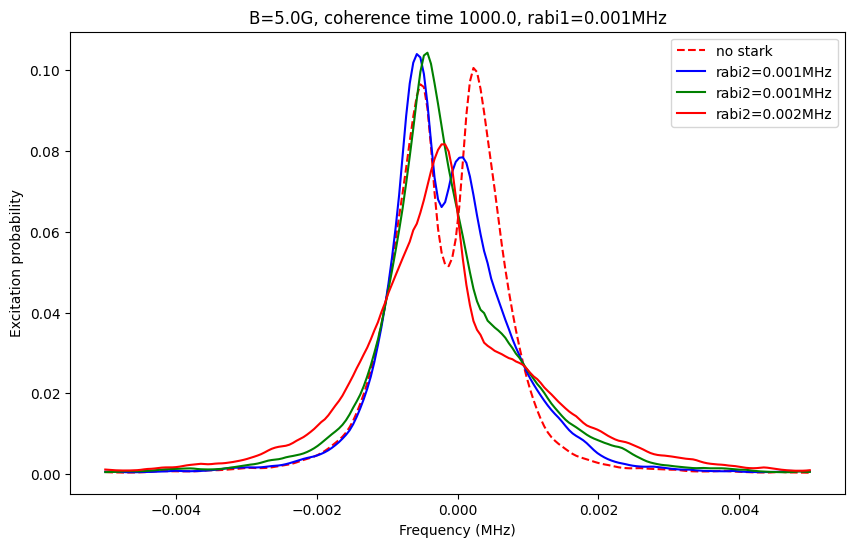

In [6]:
j_max = 50
b_fields_gauss = 5.0

caoh = CaOH.from_file(b_field_gauss=b_fields_gauss, j_max=j_max)

temperature = 300
states = qls.States(caoh, temperature)


signature_transitions = np.array([caoh.transition_df.loc[caoh.transition_df["j"]==j].iloc[0]["energy_diff"] * 1e-3 for j in range(caoh.j_max+1)])


duration_us = 1000.0
max_frequency_mhz = 0.005
scan_points = 200
dephased = True
coherence_time_us = 1000.0
is_minus = True

q1 = qls.Polarization(0, np.sqrt(0.5), np.sqrt(0.5))
q2 = qls.Polarization(0, np.sqrt(0.5), np.sqrt(0.5))
rabi_rate_mhz_1 = 2*np.pi*0.001 # Omega_1^2/delta_1, delta_1 < 0
rabi_rate_mhz_2 = 2*np.pi* np.array([0.0008, 0.001, 0.002, 0.003])



fig, ax = plt.subplots(figsize=(10, 6))
colors = ["blue", "green", "red"]

# Without AC
frequencies, exc_probs = qls.get_spectrum(caoh, states.dist, duration_us, rabi_rate_mhz_1, max_frequency_mhz, scan_points, dephased, coherence_time_us, is_minus)
plt.plot(frequencies, exc_probs, color=color, label="no stark", linestyle="--")

for r2, color in zip(rabi_rate_mhz_2, colors):
    # With AC
    ac_stark_shifts = qls.get_ac_stark_shifts(caoh, rabi_rate_mhz_1, r2, q1, q2)
    caoh.state_df["zeeman_energy_khz"] += ac_stark_shifts * 1e3
    
    caoh.transition_df = pd.DataFrame()
    caoh.init_transition_dataframe()
    
    frequencies, exc_probs = qls.get_spectrum(caoh, states.dist, duration_us, rabi_rate_mhz_1, max_frequency_mhz, scan_points, dephased, coherence_time_us, is_minus)
    plt.plot(frequencies, exc_probs, color=color, label=f"rabi2={r2/(2*np.pi):.3f}MHz")
    
plt.legend()
plt.xlabel("Frequency (MHz)")
plt.ylabel("Excitation probability")
plt.title(f"B={b_fields_gauss:.1f}G, coherence time {coherence_time_us}, rabi1={rabi_rate_mhz_1/(2*np.pi):.3f}MHz")
# plt.yscale("log")
plt.show()

### Pumping.
- Case 1: molecule under rabi1, rabi2. AC stark.
- Case 2: first, pumping. Then, rabi1 and rabi2 which produce AC stark

Data: 
- B = 2.0 G
- rabi1 = [0.005, 0.007, 0.01]
- rabi2 = 2*rabi1
- num_pumps = 100
- rabi_pump = - 0.007
- freq_pump = 0

2 state_df =         j     m     xi   spin_up  spin_down  zeeman_energy_khz  \
0      0  -0.5  False  0.000000   1.000000         -16.686203   
1      0   0.5   True  1.000000   0.000000         -25.201699   
2      1  -1.5  False  0.000000   1.000000        -134.772212   
3      1  -0.5  False  0.131139  -0.991364         -84.431915   
4      1   0.5  False  0.111001  -0.993820         -33.143137   
...   ..   ...    ...       ...        ...                ...   
5197  50  46.5   True  0.983799   0.179276        -100.386929   
5198  50  47.5   True  0.987895   0.155123        -100.384266   
5199  50  48.5   True  0.991960   0.126548        -100.381461   
5200  50  49.5   True  0.995995   0.089406        -100.378516   
5201  50  50.5   True  1.000000   0.000000        -100.375431   

      rotation_energy_ghz  
0                     0.0  
1                     0.0  
2                    22.0  
3                    22.0  
4                    22.0  
...                   ...  
5197     

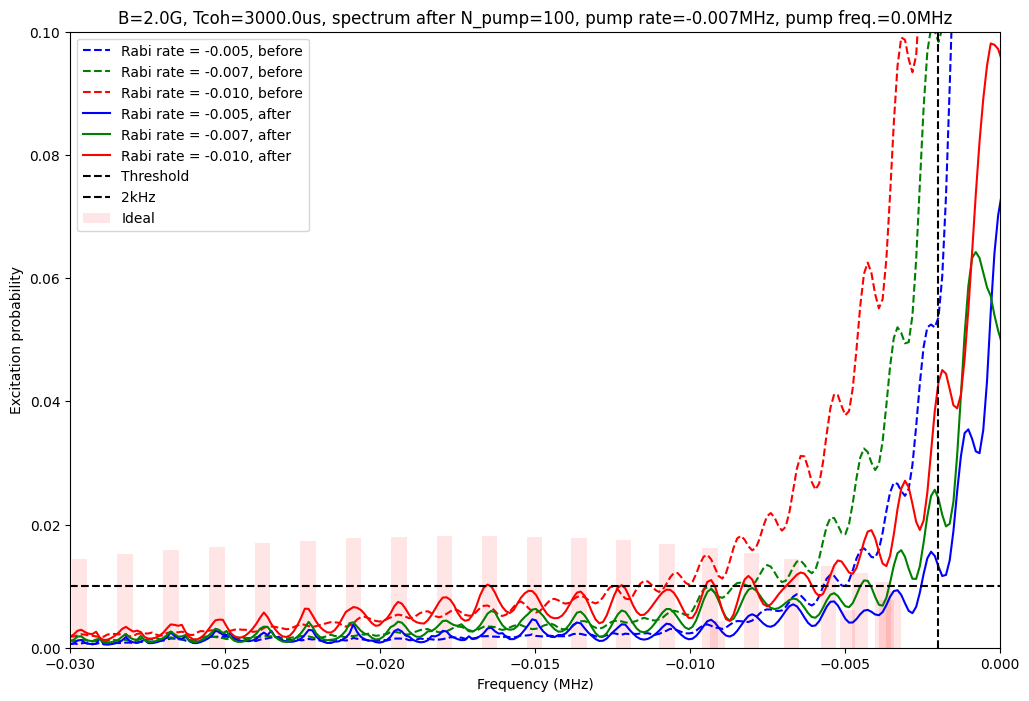

In [7]:
# A) VEDERE APPUNTI PER SPIEGAZIONE

#data
b_field_gauss = 2.0
j_max = 50
duration_us = 1000.0
colors = ["blue", "green", "red"]
max_frequency_mhz = 0.03
scan_points = 500
dephased = True
coherence_time_us = 3000.0
is_minus = True
temperature = 300

rabi_rate_mhz_1 = - 2*np.pi*np.array([0.005, 0.007, 0.01])
q1 = qls.Polarization(1, 0, 0)
q2 = qls.Polarization(0, 1, 0)

# pumping data
pump_frequency_mhz = 0.000
num_pumps = 100
pump_rabi_rate_mhz = - 2*np.pi*0.007
pump_duration_us = 1000.0

# Faccio sto passaggio solo per calcolarmi i giusti signature_transitions FINALI (credo)
mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)
states1 = qls.States(mo1, temperature)
ac_stark_shifts = qls.get_ac_stark_shifts(mo1, pump_rabi_rate_mhz, pump_rabi_rate_mhz*2., q1, q2)
mo1.state_df["zeeman_energy_khz"] += ac_stark_shifts * 1e3
mo1.transition_df = pd.DataFrame()
mo1.init_transition_dataframe()
signature_transitions = np.array([mo1.transition_df.loc[mo1.transition_df["j"]==j].iloc[0]["energy_diff"] * 1e-3 for j in range(mo1.j_max+1)])


# CASO 1) molecola sotto azione di due laser rabi1 e rabi2. 
#   - molecola inizializzata e temperatura fissa state.dist
#   - molecola sotto azione di due laser rabi1 e rabi2
#   - AC calcolata --> Modifica state_df
#   - states.dist rimane invariato. (domanda: come mai get_spectrum funziona se state1.dist è invariato? thanks to the AC, the transition_df pd has changed. so transition_df <-- get_excitation_probabilities <-- get_spectrum.)
#
fig, ax = plt.subplots(figsize=(12, 8))
for r, color in zip(rabi_rate_mhz_1, colors):
    mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)
    # print("1 state_df= ", mo1.state_df)
    # print("1 state.dist = ", states1.dist)

    ac_stark_shifts = qls.get_ac_stark_shifts(mo1, r, r*2., q1, q2)
    mo1.state_df["zeeman_energy_khz"] += ac_stark_shifts * 1e3
    mo1.transition_df = pd.DataFrame()
    mo1.init_transition_dataframe()
    frequencies, exc_probs1_after = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, coherence_time_us, is_minus)

    # print("2 state_df = ", mo1.state_df)
    # print("2 state.dist = ", states1.dist)
    plt.plot(frequencies, exc_probs1_after, label=f"Rabi rate = {r/(2*np.pi):.3f}, before", linestyle="--", color=color)


# CASO 2) molecola sotto azione prima del laser di pumping, poi dei due laser rabi1 e rabi2. 
#   - pumping: states1.dist viene modificato. (fino a qui state_df è uguale a  "1 state_df")
#   - successivamente, molecola sotto azione di due laser rabi1 e rabi2
#   - AC calcolata --> Modifica state_df (con rabi1 e rabi2)
#   - states.dist rimane invariato, ossia rimane quello dopo il pumping. (domanda: come mai get_spectrum funziona se state1.dist è invariato? thanks to the AC, the transition_df pd has changed. so transition_df <-- get_excitation_probabilities <-- get_spectrum.)
#
print("2 state_df = ", mo1.state_df)
print("2 state.dist = ", states1.dist)
for _ in range(num_pumps):
    states1.dist += qls.excitation_matrix(mo1, pump_frequency_mhz, pump_duration_us, pump_rabi_rate_mhz, dephased, coherence_time_us, is_minus).dot(states1.dist)


for r, color in zip(rabi_rate_mhz_1, colors):
    mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)
    print("3 state_df = ", mo1.state_df)
    print("3 state.dist = ", states1.dist)
    ac_stark_shifts = qls.get_ac_stark_shifts(mo1, r, r*2., q1, q2)
    mo1.state_df["zeeman_energy_khz"] += ac_stark_shifts * 1e3
    mo1.transition_df = pd.DataFrame()
    mo1.init_transition_dataframe()
    frequencies, exc_probs1_after = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, coherence_time_us, is_minus)
    print("4 state_df = ", mo1.state_df)
    print("4 state.dist = ", states1.dist)
    plt.plot(frequencies, exc_probs1_after, label=f"Rabi rate = {r/(2*np.pi):.3f}, after", color=color)


ax.bar(signature_transitions, states1.j_distribution()*0.5, color="red", width=0.0005, alpha=0.1, label="Ideal")
ax.hlines(0.01, -max_frequency_mhz, max_frequency_mhz, color="black", linestyle="--", label="Threshold")
ax.vlines(-0.002, 0, 0.1, color="black", linestyle="--", label="2kHz")
ax.legend()
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Excitation probability")
ax.set_title(f"B={b_field_gauss}G, Tcoh={coherence_time_us}us, spectrum after N_pump={num_pumps}, pump rate={pump_rabi_rate_mhz/(2*np.pi):.3f}MHz, pump freq.={pump_frequency_mhz}MHz")
ax.set_xlim([-max_frequency_mhz, 0])
ax.set_ylim([0, 0.1])
plt.show()

ho rifatto la stessa cosa di sopra mettendo tutto dentro un unico ciclo for. ma per il fatto che così il pumping viene fatto su quella molecola lì, altrimenti non so su cosa si faccia il pumping. indagare meglio

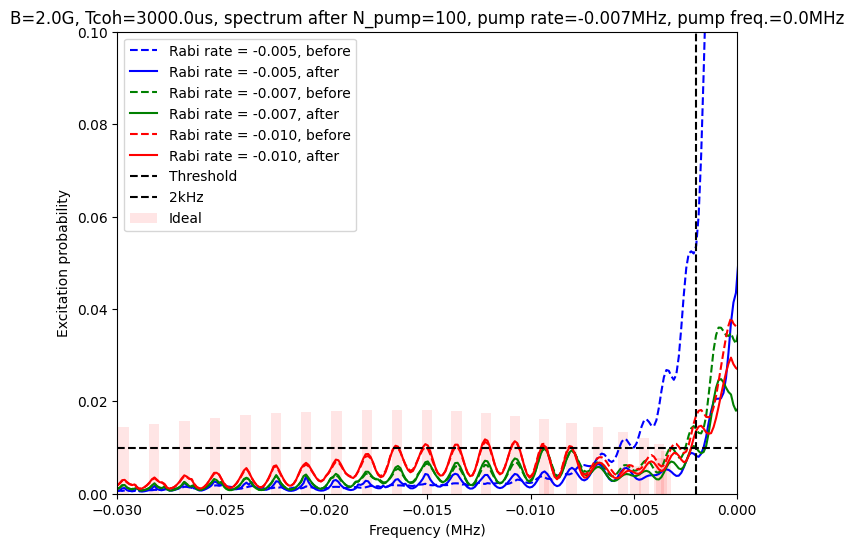

In [8]:
# A) VEDERE APPUNTI PER SPIEGAZIONE

#data
b_field_gauss = 2.0
j_max = 50
duration_us = 1000.0
colors = ["blue", "green", "red"]
max_frequency_mhz = 0.03
scan_points = 500
dephased = True
coherence_time_us = 3000.0
is_minus = True
temperature = 300

rabi_rate_mhz_1 = - 2*np.pi*np.array([0.005, 0.007, 0.01])
q1 = qls.Polarization(1, 0, 0)
q2 = qls.Polarization(0, 1, 0)

# pumping data
pump_frequency_mhz = 0.000
num_pumps = 100
pump_rabi_rate_mhz = - 2*np.pi*0.007
pump_duration_us = 1000.0

# Faccio sto passaggio solo per calcolarmi i giusti signature_transitions FINALI (credo)
mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)
states1 = qls.States(mo1, temperature)
ac_stark_shifts = qls.get_ac_stark_shifts(mo1, pump_rabi_rate_mhz, pump_rabi_rate_mhz*2., q1, q2)
mo1.state_df["zeeman_energy_khz"] += ac_stark_shifts * 1e3
mo1.transition_df = pd.DataFrame()
mo1.init_transition_dataframe()
signature_transitions = np.array([mo1.transition_df.loc[mo1.transition_df["j"]==j].iloc[0]["energy_diff"] * 1e-3 for j in range(mo1.j_max+1)])



# CASO 1) molecola sotto azione di due laser rabi1 e rabi2. 
#   - molecola inizializzata e temperatura fissa state.dist
#   - molecola sotto azione di due laser rabi1 e rabi2
#   - AC calcolata --> Modifica state_df
#   - states.dist rimane invariato. (domanda: come mai get_spectrum funziona se state1.dist è invariato? thanks to the AC, the transition_df pd has changed. so transition_df <-- get_excitation_probabilities <-- get_spectrum.)
#
fig, ax = plt.subplots(figsize=(8, 6))
for r, color in zip(rabi_rate_mhz_1, colors):
    mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)
    # print("1 state_df= ", mo1.state_df)
    # print("1 state.dist = ", states1.dist)

    ac_stark_shifts = qls.get_ac_stark_shifts(mo1, r, r*2., q1, q2)
    mo1.state_df["zeeman_energy_khz"] += ac_stark_shifts * 1e3
    mo1.transition_df = pd.DataFrame()
    mo1.init_transition_dataframe()
    frequencies, exc_probs1_after = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, coherence_time_us, is_minus)

    # print("2 state_df = ", mo1.state_df)
    # print("2 state.dist = ", states1.dist)
    plt.plot(frequencies, exc_probs1_after, label=f"Rabi rate = {r/(2*np.pi):.3f}, before", linestyle="--", color=color)


# CASO 2) molecola sotto azione prima del laser di pumping, poi dei due laser rabi1 e rabi2. 
#   - pumping: states1.dist viene modificato. (fino a qui state_df è uguale a  "1 state_df")
#   - successivamente, molecola sotto azione di due laser rabi1 e rabi2
#   - AC calcolata --> Modifica state_df (con rabi1 e rabi2)
#   - states.dist rimane invariato, ossia rimane quello dopo il pumping. (domanda: come mai get_spectrum funziona se state1.dist è invariato? thanks to the AC, the transition_df pd has changed. so transition_df <-- get_excitation_probabilities <-- get_spectrum.)
#
    # print("2 state_df = ", mo1.state_df)
    # print("2 state.dist = ", states1.dist)
    for _ in range(num_pumps):
        states1.dist += qls.excitation_matrix(mo1, pump_frequency_mhz, pump_duration_us, pump_rabi_rate_mhz, dephased, coherence_time_us, is_minus).dot(states1.dist)
    # print("2_bis state_df = ", mo1.state_df)
    # print("2_bis state.dist = ", states1.dist)

# for r, color in zip(rabi_rate_mhz_1, colors):
    mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)
    # print("3 state_df = ", mo1.state_df)
    # print("3 state.dist = ", states1.dist)
    ac_stark_shifts = qls.get_ac_stark_shifts(mo1, r, r*2., q1, q2)
    mo1.state_df["zeeman_energy_khz"] += ac_stark_shifts * 1e3
    mo1.transition_df = pd.DataFrame()
    mo1.init_transition_dataframe()
    frequencies, exc_probs1_after = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, coherence_time_us, is_minus)
    # print("4 state_df = ", mo1.state_df)
    # print("4 state.dist = ", states1.dist)
    plt.plot(frequencies, exc_probs1_after, label=f"Rabi rate = {r/(2*np.pi):.3f}, after", color=color)


ax.bar(signature_transitions, states1.j_distribution()*0.5, color="red", width=0.0005, alpha=0.1, label="Ideal")

ax.hlines(0.01, -max_frequency_mhz, max_frequency_mhz, color="black", linestyle="--", label="Threshold")
ax.vlines(-0.002, 0, 0.1, color="black", linestyle="--", label="2kHz")
ax.legend()
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Excitation probability")
ax.set_title(f"B={b_field_gauss}G, Tcoh={coherence_time_us}us, spectrum after N_pump={num_pumps}, pump rate={pump_rabi_rate_mhz/(2*np.pi):.3f}MHz, pump freq.={pump_frequency_mhz}MHz")
ax.set_xlim([-max_frequency_mhz, 0])
ax.set_ylim([0, 0.1])
plt.show()

-0.06283185307179587
-0.06283185307179587


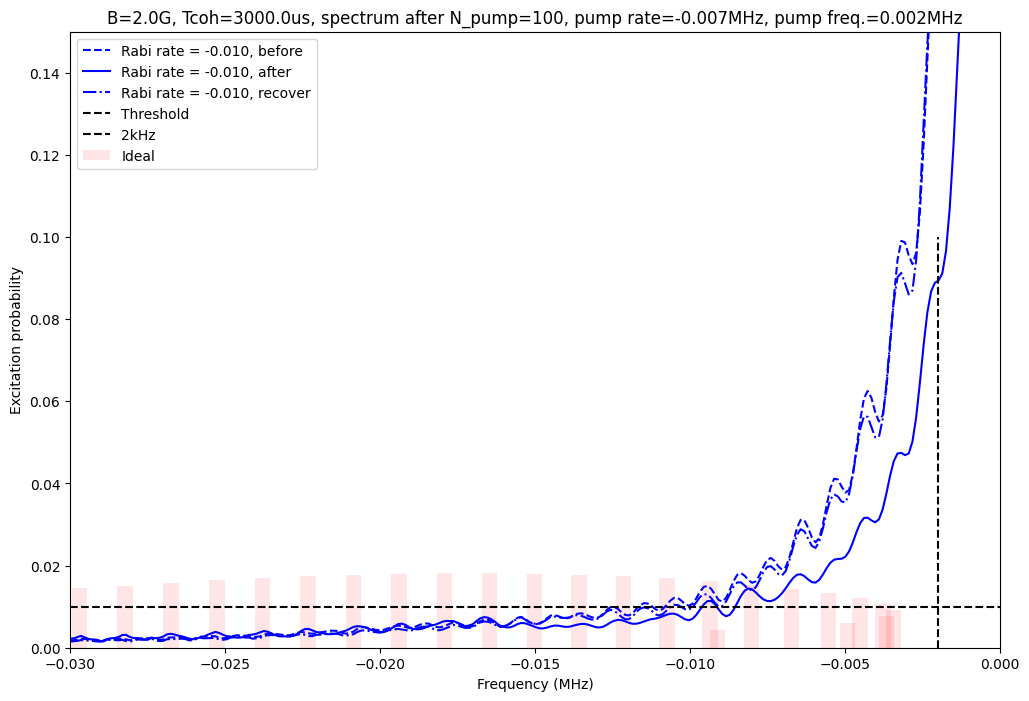

In [3]:
# I think here we are trying to recover the initial state by pumping with
# is_minus = True, and then pumping back with is_minus = False


b_field_gauss = 2.0
j_max = 50
duration_us = 1000.0
colors = ["blue", "green", "red"]
max_frequency_mhz = 0.03
scan_points = 500
dephased = True
coherence_time_us = 3000.0
is_minus = True
temperature = 300

rabi_rate_mhz_1 = - 2*np.pi*np.array([0.01])
q1 = qls.Polarization(1, 0, 0)
q2 = qls.Polarization(0, 1, 0)

# pumping data
pump_frequency_mhz = 0.002
num_pumps = 100
pump_rabi_rate_mhz = - 2*np.pi*0.007
pump_duration_us = 1000.0

# Faccio sto passaggio solo per calcolarmi i giusti signature_transitions FINALI (credo)
mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)
states1 = qls.States(mo1, temperature)
ac_stark_shifts = qls.get_ac_stark_shifts(mo1, pump_rabi_rate_mhz, pump_rabi_rate_mhz*2., q1, q2)
mo1.state_df["zeeman_energy_khz"] += ac_stark_shifts * 1e3
mo1.transition_df = pd.DataFrame()
mo1.init_transition_dataframe()
signature_transitions = np.array([mo1.transition_df.loc[mo1.transition_df["j"]==j].iloc[0]["energy_diff"] * 1e-3 for j in range(mo1.j_max+1)])

fig, ax = plt.subplots(figsize=(12, 8))
for r, color in zip(rabi_rate_mhz_1, colors):
    print(r)
    mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)
    ac_stark_shifts = qls.get_ac_stark_shifts(mo1, r, r*2., q1, q2)
    mo1.state_df["zeeman_energy_khz"] += ac_stark_shifts * 1e3
    mo1.transition_df = pd.DataFrame()
    mo1.init_transition_dataframe()
    print(r)
    frequencies, exc_probs1_after = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, coherence_time_us, is_minus)
    plt.plot(frequencies, exc_probs1_after, label=f"Rabi rate = {r/(2*np.pi):.3f}, before", linestyle="--", color=color)

for _ in range(num_pumps):
    states1.dist += qls.excitation_matrix(mo1, pump_frequency_mhz, pump_duration_us, pump_rabi_rate_mhz, dephased, coherence_time_us, is_minus).dot(states1.dist)

for r, color in zip(rabi_rate_mhz_1, colors):
    mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)
    ac_stark_shifts = qls.get_ac_stark_shifts(mo1, r, r*2., q1, q2)
    mo1.state_df["zeeman_energy_khz"] += ac_stark_shifts * 1e3
    mo1.transition_df = pd.DataFrame()
    mo1.init_transition_dataframe()
    frequencies, exc_probs1_after = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, coherence_time_us, is_minus)
    plt.plot(frequencies, exc_probs1_after, label=f"Rabi rate = {r/(2*np.pi):.3f}, after", color=color)

for _ in range(num_pumps):
    states1.dist += qls.excitation_matrix(mo1, pump_frequency_mhz, pump_duration_us, pump_rabi_rate_mhz, dephased, coherence_time_us, False).dot(states1.dist)

for r, color in zip(rabi_rate_mhz_1, colors):
    mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)
    ac_stark_shifts = qls.get_ac_stark_shifts(mo1, r, r*2., q1, q2)
    mo1.state_df["zeeman_energy_khz"] += ac_stark_shifts * 1e3
    mo1.transition_df = pd.DataFrame()
    mo1.init_transition_dataframe()
    frequencies, exc_probs1_after = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, coherence_time_us, is_minus)
    plt.plot(frequencies, exc_probs1_after, label=f"Rabi rate = {r/(2*np.pi):.3f}, recover", color=color, linestyle="-.")

ax.bar(signature_transitions, states1.j_distribution()*0.5, color="red", width=0.0005, alpha=0.1, label="Ideal")
ax.hlines(0.01, -max_frequency_mhz, max_frequency_mhz, color="black", linestyle="--", label="Threshold")
ax.vlines(-0.002, 0, 0.1, color="black", linestyle="--", label="2kHz")
ax.legend()
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Excitation probability")
ax.set_title(f"B={b_field_gauss}G, Tcoh={coherence_time_us}us, spectrum after N_pump={num_pumps}, pump rate={pump_rabi_rate_mhz/(2*np.pi):.3f}MHz, pump freq.={pump_frequency_mhz}MHz")
ax.set_xlim([-max_frequency_mhz, 0])
ax.set_ylim([0, 0.15])
plt.show()

### Thermal considerations

In [109]:
mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=50)
states1 = qls.States(mo1, temperature)

In [110]:
mo1.state_df

,j,m,xi,spin_up,spin_down,zeeman_energy_khz,rotation_energy_ghz
0,0,-0.5,False,0.000000,1.000000,4.257748,0.0
1,0,0.5,True,1.000000,0.000000,-4.257748,0.0
2,1,-1.5,False,0.000000,1.000000,3.457865,22.0
3,1,-0.5,False,0.131139,-0.991364,4.397118,22.0
4,1,0.5,False,0.111001,-0.993820,5.175307,22.0
...,...,...,...,...,...,...,...
5197,50,46.5,True,0.983799,0.179276,-38.677315,28050.0
5198,50,47.5,True,0.987895,0.155123,-38.699100,28050.0
5199,50,48.5,True,0.991960,0.126548,-38.720745,28050.0
5200,50,49.5,True,0.995995,0.089406,-38.742249,28050.0


In [111]:
states1.dist

array([8.88471192e-04, 8.88471192e-04, 8.85349763e-04, ...,
       9.99624928e-06, 9.99624928e-06, 9.99624928e-06])

In [112]:
states1.j_distribution()        # in teoria sono la somma delle probabilità con lo stesso J. quindi in teoria è 2*(2j+1)*exp(- ...)

array([0.00177694, 0.0053121 , 0.0087914 , 0.01217869, 0.01543942,
       0.01854125, 0.02145452, 0.02415279, 0.0266132 , 0.02881679,
       0.03074868, 0.03239827, 0.03375921, 0.03482939, 0.03561077,
       0.03610921, 0.03633412, 0.03629816, 0.03601685, 0.03550811,
       0.03479184, 0.03388941, 0.03282325, 0.03161637, 0.03029192,
       0.02887281, 0.02738132, 0.0258388 , 0.02426538, 0.02267976,
       0.02109901, 0.01953845, 0.01801157, 0.01653002, 0.01510357,
       0.01374017, 0.01244605, 0.01122577, 0.0100824 , 0.00901757,
       0.00803172, 0.00712417, 0.00629331, 0.00553675, 0.00485146,
       0.00423392, 0.00368022, 0.00318623, 0.00274763, 0.00236008,
       0.00201924])

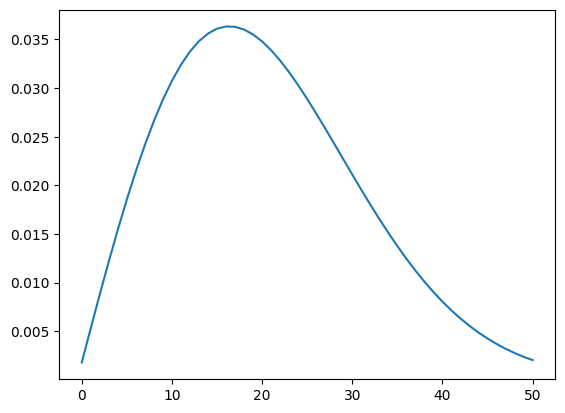

In [114]:
plt.plot(np.arange(51), states1.j_distribution())

In [115]:
temperature = 300

rotational_energy_hz = mo1.state_df["rotation_energy_ghz"]   
state_distribution = np.exp(-h * rotational_energy_hz * 1e9 / (k * temperature))

# Normalizzazione
state_distribution /= np.sum(state_distribution)

# Aggiunta della colonna "dist"
mo1.state_df["dist"] = state_distribution       # corrispondono a state1.dist

mo1.state_df

,j,m,xi,spin_up,spin_down,zeeman_energy_khz,rotation_energy_ghz,dist
0,0,-0.5,False,0.000000,1.000000,4.257748,0.0,0.000888
1,0,0.5,True,1.000000,0.000000,-4.257748,0.0,0.000888
2,1,-1.5,False,0.000000,1.000000,3.457865,22.0,0.000885
3,1,-0.5,False,0.131139,-0.991364,4.397118,22.0,0.000885
4,1,0.5,False,0.111001,-0.993820,5.175307,22.0,0.000885
...,...,...,...,...,...,...,...,...
5197,50,46.5,True,0.983799,0.179276,-38.677315,28050.0,0.000010
5198,50,47.5,True,0.987895,0.155123,-38.699100,28050.0,0.000010
5199,50,48.5,True,0.991960,0.126548,-38.720745,28050.0,0.000010
5200,50,49.5,True,0.995995,0.089406,-38.742249,28050.0,0.000010


In [117]:
state_dist = states1.dist       # len() = 5201. uno per ogni riga di state_df

unique_dist = list(dict.fromkeys(state_dist))    # sono i valori unici, uno per ogni j. len() = 51
print(unique_dist)

Js = np.arange(51)      # [0, 1, 2, 3, 4 ...]
print(Js)

pr = unique_dist * (2*Js + 1)*2       # se normalizzato equivale a states1.j_distribution(), perchjè equivale a fare (2j+1)*2 * exp(- ...)
print(pr)

pr = pr/np.sum(pr)
print(pr)

[np.float64(0.0008884711922725841), np.float64(0.0008853497629192616), np.float64(0.0008791397648535321), np.float64(0.000869906343468254), np.float64(0.0008577457912433485), np.float64(0.0008427838760869817), np.float64(0.0008251736762624252), np.float64(0.00080509297401286), np.float64(0.0007827412699184376), np.float64(0.000758336488046522), np.float64(0.0007321114478730382), np.float64(0.0007043101826235705), np.float64(0.0006751841850515264), np.float64(0.0006449886607625138), np.float64(0.0006139788661118717), np.float64(0.0005824066026200413), np.float64(0.0005505169330041847), np.float64(0.0005185451756008833), np.float64(0.00048671422447830423), np.float64(0.00045523223225516656), np.float64(0.00042429068191595883), np.float64(0.00039406286309063334), np.float64(0.0003647027576885791), np.float64(0.00033634432974842716), np.float64(0.00030910120515607387), np.float64(0.00028306671871624744), np.float64(0.00025831429911002656), np.float64(0.0002348981566503272), np.float64(0.00

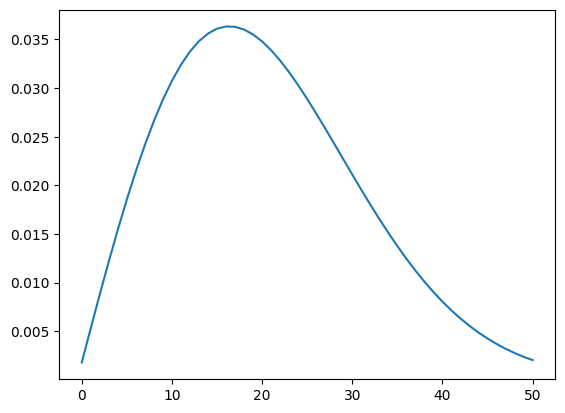

In [118]:
plt.plot(Js, pr)